# Vertical Reflectivity Gradient Histogram by Storm Type

**Authors:** Jim Steenburgh, Ashley Evans, Michael Wasserstein  
**Date:** January 2025

This notebook computes and plots histograms of the **vertical reflectivity gradient (VRG)**
derived from Micro Rain Radar (MRR) observations at two mountain sites:

- **Alta Atwater** (Alta, UT)
- **Highland High** (Highland, UT)

Three storm-type case studies are analysed:

| Label | Event | Period (UTC) |
|-------|-------|--------------|
| S/SWIVT | South/Southwest flow with high IVT | 2023-01-09 23:00 – 2023-01-10 11:00 |
| Frontal (FR) | Frontal | 2023-02-21 23:00 – 2023-02-22 11:00 |
| NW Postfrontal (NWPF) | Northwest Postfrontal | 2022-12-13 23:00 – 2022-12-14 11:00 |

The VRG is computed by fitting a linear regression to the reflectivity profile between
configurable height bounds at each time step. The distribution of slopes is then plotted
as a histogram for each event type and site.

The VRG equation calculated as:

$$\mathrm{VRG} = \frac{\sum_{i=1}^{n} (z_i - \bar{z})(Z_{e,i} - \bar{Z}_e)}{\sum_{i=1}^{n} (z_i - \bar{z})^2}$$

In [13]:
import os
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from scipy.stats import linregress
import pandas as pd
import math

In [14]:
# Path where the MRR data are stored
HOME = '/uufs/chpc.utah.edu/common/home/steenburgh-group12/peter/WasatchDeployment_2022_2024_fromLaptop'

# Directory where figures will be saved
output_dir = 'Fig'
os.makedirs(output_dir, exist_ok=True)


## Data Loading Functions

In [15]:
def prepare_data(files, start_time, end_time):
    """
    Read and preprocess a list of MRR NetCDF files into a clean xarray Dataset.

    Parameters
    ----------
    files : list of str
        Paths to the MRR NetCDF files to open.
    start_time : str
        ISO-format start time for the time slice.
    end_time : str
        ISO-format end time for the time slice.

    Returns
    -------
    data : xr.Dataset
        Dataset with time as a proper datetime coordinate and height_ASL
        (height above sea level) as the vertical dimension.
    MRR_elevation : float
        Elevation of the MRR instrument (m ASL).
    """
    data = xr.open_mfdataset(files)
    data['time'] = pd.to_datetime(data.time.values, unit='s')
    data = data.drop_duplicates(dim='time', keep=False)
    data = data.sortby('time')
    data = data.sel(time=slice(start_time, end_time))

    # Replace physically unreasonable values with NaN
    for var in ('Ze', 'spectralWidth', 'W'):
        data[var].values = np.where(
            (data[var] < -1000) | (data[var] > 1000), np.nan, data[var]
        )

    # Convention: positive W is upward (away from MRR)
    data['W'] *= -1

    height = data.height.values[0]
    try:
        MRR_elevation = data.MRR_elevation.values[0]
    except Exception:
        MRR_elevation = data.MRR_elevation.values

    data = data.drop_vars(['lat', 'lon', 'height', 'MRR_elevation'])

    # Add height above sea level as the vertical coordinate
    height_ASL = height + MRR_elevation
    data = data.rename_dims({'range': 'height_ASL'}).assign_coords(height_ASL=height_ASL)
    data = data.assign_coords(height=('height_ASL', height))

    return data, MRR_elevation

In [16]:
def get_files(time_period_start, time_period_end):
    """
    Build lists of MRR NetCDF file paths for Alta and Highland sites.

    Parameters
    ----------
    time_period_start : str
        ISO-format start time.
    time_period_end : str
        ISO-format end time.

    Returns
    -------
    files_30_Alta, files_180_Alta : list of str
        30 m and 180 m range-gate files for the Alta site.
    files_30_Highland, files_180_Highland : list of str
        30 m and 180 m range-gate files for the Highland site.
    """
    dates_to_plot = pd.date_range(time_period_start, time_period_end, freq='12h')

    result = {}
    for site in ('Alta', 'Highland'):
        data_dir = os.path.join(
            HOME, site, 'MRR', 'NetCDF'
        )
        files_30, files_180 = [], []
        for date in dates_to_plot:
            year  = date.year
            month = str(date.month).zfill(2)
            day   = str(date.day).zfill(2)
            f30  = os.path.join(data_dir, f'{year}{month}', f'condensed_processed_{month}{day}_030m.nc')
            f180 = os.path.join(data_dir, f'{year}{month}', f'condensed_processed_{month}{day}_180m.nc')
            if f30  not in files_30:  files_30.append(f30)
            if f180 not in files_180: files_180.append(f180)
        result[site] = (files_30, files_180)

    return (result['Alta'][0], result['Alta'][1],
            result['Highland'][0], result['Highland'][1])

## Analysis Functions

In [17]:
def reflectivity_slope_histogram(ds, min_height=900, max_height=1980):
    """
    Compute the vertical reflectivity gradient (VRG) at each time step.

    For each time step a linear regression is fitted to the reflectivity
    profile between `min_height` and `max_height`. The slope of that fit
    (dBZ km⁻¹) is the VRG. Time steps that lack data at the lowest or
    highest level are excluded.

    Parameters
    ----------
    ds : xr.Dataset
        MRR dataset containing 'Ze' and 'height' coordinates.
    min_height : float
        Lower bound of the height range (m AGL).
    max_height : float
        Upper bound of the height range (m AGL).

    Returns
    -------
    slopes : np.ndarray
        VRG (dBZ km⁻¹) at each time step (NaN where excluded).
    count_nan : int
        Number of time steps with NaN slopes.
    min_height, max_height : float
        The height bounds used (passed through for convenience).
    list_bars : list of int
        Counts of three missing-data scenarios:
        [bottom_nan_top_valid, bottom_nan_top_nan, bottom_valid_top_nan].
    """
    count_bottom_nan_top_not = 0
    count_bottom_not_top_nan = 0
    count_bottom_nan_top_nan = 0

    min_ind = np.where(ds.height.values == min_height)[0][0]
    max_ind = np.where(ds.height.values == max_height)[0][0]

    time_len = ds.sizes['time']
    # Convert height to km so slope units are dBZ km⁻¹
    height_subset = ds.height.values[min_ind:max_ind + 1] / 1000.0

    slopes     = np.full(time_len, np.nan)
    intercepts = np.full(time_len, np.nan)
    r_values   = np.full(time_len, np.nan)

    for i in range(time_len):
        refl_profile = ds.isel(time=i).Ze.values[min_ind:max_ind + 1]
        mask = ~np.isnan(refl_profile)

        bottom_valid = ~np.isnan(refl_profile[0])
        top_valid    = ~np.isnan(refl_profile[-1])

        # Require data at both the lowest and highest level
        if np.sum(mask) >= 2 and bottom_valid and top_valid:
            slope, intercept, r_value, _, _ = linregress(height_subset[mask], refl_profile[mask])
            slopes[i]     = slope
            intercepts[i] = intercept
            r_values[i]   = r_value

        if not bottom_valid and top_valid:
            count_bottom_nan_top_not += 1
        if bottom_valid and not top_valid:
            count_bottom_not_top_nan += 1
        if not bottom_valid and not top_valid:
            count_bottom_nan_top_nan += 1

    count_nan = int(np.sum(np.isnan(slopes)))
    list_bars = [count_bottom_nan_top_not, count_bottom_nan_top_nan, count_bottom_not_top_nan]

    return slopes, count_nan, min_height, max_height, list_bars

## Event Time Periods

In [18]:
# Each entry is (start_time_UTC, end_time_UTC, label)
time_period_SIVT = [('2023-01-09 23:00:00', '2023-01-10 11:00:00', 'SIVT')]
time_period_FR   = [('2023-02-21 23:00:00', '2023-02-22 11:00:00', 'FR')]
time_period_NWPF = [('2022-12-13 23:00:00', '2022-12-14 11:00:00', 'NWPF')]

## Load MRR Data

Read 30 m and 180 m range-gate MRR data for both sites and all three events.

In [19]:
# ---- S/SWIVT ----
files_30_Alta, files_180_Alta, files_30_Highland, files_180_Highland = get_files(
    time_period_SIVT[0][0], time_period_SIVT[0][1]
)
ds_180_Alta,     MRR_elevation_Alta     = prepare_data(files_180_Alta,     *time_period_SIVT[0][:2])
ds_30_Alta,      _                      = prepare_data(files_30_Alta,      *time_period_SIVT[0][:2])
ds_180_Highland, MRR_elevation_Highland = prepare_data(files_180_Highland, *time_period_SIVT[0][:2])
ds_30_Highland,  _                      = prepare_data(files_30_Highland,  *time_period_SIVT[0][:2])

# Select for the time of interst
alta180_SIVT    = ds_180_Alta.sel(time=slice(*time_period_SIVT[0][:2]))
alta30_SIVT     = ds_30_Alta.sel(time=slice(*time_period_SIVT[0][:2]))
highland180_SIVT = ds_180_Highland.sel(time=slice(*time_period_SIVT[0][:2]))
highland30_SIVT  = ds_30_Highland.sel(time=slice(*time_period_SIVT[0][:2]))

# ---- Frontal ----
files_30_Alta, files_180_Alta, files_30_Highland, files_180_Highland = get_files(
    time_period_FR[0][0], time_period_FR[0][1]
)
ds_180_Alta,     _ = prepare_data(files_180_Alta,     *time_period_FR[0][:2])
ds_30_Alta,      _ = prepare_data(files_30_Alta,      *time_period_FR[0][:2])
ds_180_Highland, _ = prepare_data(files_180_Highland, *time_period_FR[0][:2])
ds_30_Highland,  _ = prepare_data(files_30_Highland,  *time_period_FR[0][:2])

# Select for the time of interst
alta180_FR    = ds_180_Alta.sel(time=slice(*time_period_FR[0][:2]))
alta30_FR     = ds_30_Alta.sel(time=slice(*time_period_FR[0][:2]))
highland180_FR = ds_180_Highland.sel(time=slice(*time_period_FR[0][:2]))
highland30_FR  = ds_30_Highland.sel(time=slice(*time_period_FR[0][:2]))

# ---- NW Postfrontal ----
files_30_Alta, files_180_Alta, files_30_Highland, files_180_Highland = get_files(
    time_period_NWPF[0][0], time_period_NWPF[0][1]
)
ds_180_Alta,     _ = prepare_data(files_180_Alta,     *time_period_NWPF[0][:2])
ds_30_Alta,      _ = prepare_data(files_30_Alta,      *time_period_NWPF[0][:2])
ds_180_Highland, _ = prepare_data(files_180_Highland, *time_period_NWPF[0][:2])
ds_30_Highland,  _ = prepare_data(files_30_Highland,  *time_period_NWPF[0][:2])

# Select for the time of interst
alta180_NWPF    = ds_180_Alta.sel(time=slice(*time_period_NWPF[0][:2]))
alta30_NWPF     = ds_30_Alta.sel(time=slice(*time_period_NWPF[0][:2]))
highland180_NWPF = ds_180_Highland.sel(time=slice(*time_period_NWPF[0][:2]))
highland30_NWPF  = ds_30_Highland.sel(time=slice(*time_period_NWPF[0][:2]))

## Compute Vertical Reflectivity Gradients

The VRG is computed using reflectivity profiles from the 30 m range-gate instrument
between the height bounds defined below.

In [20]:
# Height range for the VRG regression (meters AGL)
# 120 m is the lowest usable range gate for the 30 m instrument;
# 900 m is the highest usable gate (930 m is excluded).
min_height = 120
max_height = 900

In [21]:
# Alta VRG
reflectivity_slope_Alta_SIVT,    count_nan_Alta_SIVT,    _, _, _ = reflectivity_slope_histogram(alta30_SIVT,    min_height, max_height)
reflectivity_slope_Alta_FR,      count_nan_Alta_FR,      _, _, _ = reflectivity_slope_histogram(alta30_FR,      min_height, max_height)
reflectivity_slope_Alta_NWPF,    count_nan_Alta_NWPF,    _, _, _ = reflectivity_slope_histogram(alta30_NWPF,    min_height, max_height)

# Highland VRG
reflectivity_slope_Highland_SIVT, count_nan_Highland_SIVT, _, _, _ = reflectivity_slope_histogram(highland30_SIVT, min_height, max_height)
reflectivity_slope_Highland_FR,   count_nan_Highland_FR,   _, _, _ = reflectivity_slope_histogram(highland30_FR,   min_height, max_height)
reflectivity_slope_Highland_NWPF, count_nan_Highland_NWPF, _, _, _ = reflectivity_slope_histogram(highland30_NWPF, min_height, max_height)

## Plot Histograms

In [22]:
# Settings for the plot
matplotlib.rcParams['axes.facecolor']       = [1, 1, 1, 1]
matplotlib.rcParams['axes.edgecolor']       = 'black'
matplotlib.rcParams['axes.labelsize']       = 14
matplotlib.rcParams['axes.titlesize']       = 14
matplotlib.rcParams['xtick.labelsize']      = 12
matplotlib.rcParams['ytick.labelsize']      = 12
matplotlib.rcParams['legend.fontsize']      = 10
matplotlib.rcParams['legend.facecolor']     = 'w'
matplotlib.rcParams['legend.edgecolor']     = 'gray'
matplotlib.rcParams['savefig.transparent']  = False
matplotlib.rcParams['xtick.major.width']    = 1
matplotlib.rcParams['xtick.major.size']     = 8
matplotlib.rcParams['ytick.major.width']    = 1
matplotlib.rcParams['ytick.major.size']     = 8

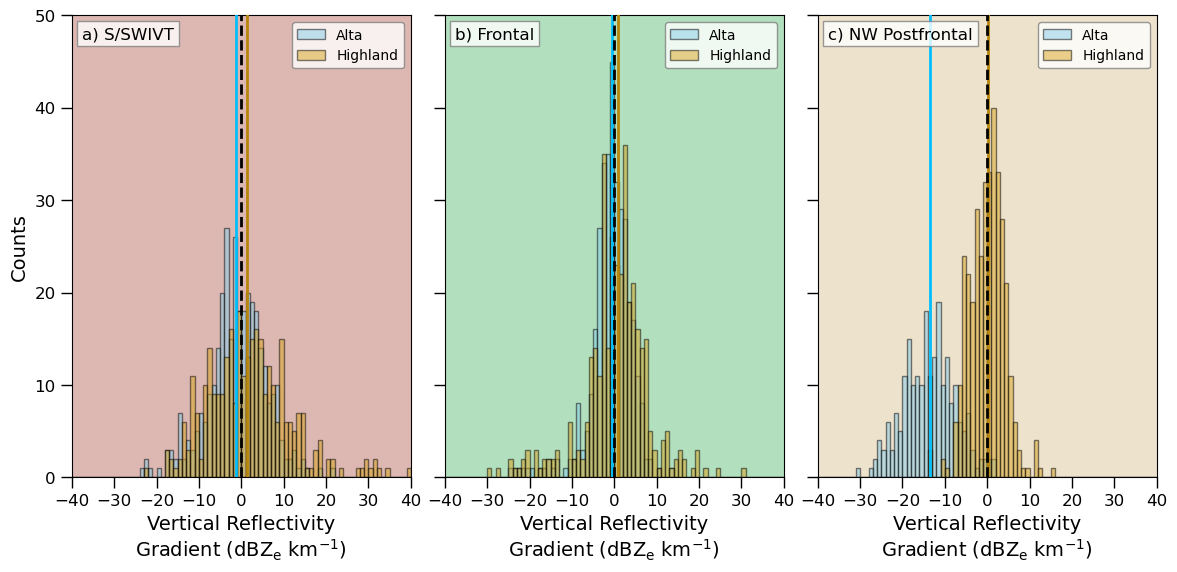

In [23]:
# Settings
hist_bins = np.arange(-0.05, 0.06, 0.001) * 1000  # dBZ km⁻¹
hist_kw   = dict(bins=hist_bins, edgecolor='k')
label_kw  = dict(fontsize=14)
vline_kw  = dict(zorder=19, linewidth=2)
props     = dict(boxstyle='square', facecolor='white', alpha=0.8, ec='gray')

# Create fig and axis
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, facecolor='white', edgecolor='k', sharey=True, figsize=(14, 6)
)

# ── Panel a: S/SWIVT ──────────────────────────────────────────────────────────
ax1.hist(reflectivity_slope_Alta_SIVT,     color='skyblue',   alpha=0.5, label='Alta',     **hist_kw)
ax1.hist(reflectivity_slope_Highland_SIVT, color='goldenrod', alpha=0.5, label='Highland', **hist_kw)
ax1.vlines(np.nanmedian(reflectivity_slope_Alta_SIVT),     0, 500, colors='deepskyblue',   **vline_kw)
ax1.vlines(np.nanmedian(reflectivity_slope_Highland_SIVT), 0, 500, colors='darkgoldenrod', **vline_kw)
ax1.set_facecolor(to_rgba('xkcd:brick red', alpha=0.3))
ax1.text(0.03, 0.95, 'a) S/SWIVT', transform=ax1.transAxes, fontsize=12, bbox=props, zorder=50000)
ax1.set_xlabel('Vertical Reflectivity\n' + r'Gradient (dBZ$_\mathrm{e}$ km$^{-1}$)', **label_kw)
ax1.set_ylabel('Counts', **label_kw)
ax1.legend()

# ── Panel b: Frontal ──────────────────────────────────────────────────────────
ax2.hist(reflectivity_slope_Alta_FR,     color='skyblue',   alpha=0.5, label='Alta',     **hist_kw)
ax2.hist(reflectivity_slope_Highland_FR, color='goldenrod', alpha=0.5, label='Highland', **hist_kw)
ax2.vlines(np.nanmedian(reflectivity_slope_Alta_FR),     0, 500, colors='deepskyblue',   **vline_kw)
ax2.vlines(np.nanmedian(reflectivity_slope_Highland_FR), 0, 500, colors='darkgoldenrod', **vline_kw)
ax2.set_facecolor(to_rgba('xkcd:irish green', alpha=0.3))
ax2.text(0.03, 0.95, 'b) Frontal', transform=ax2.transAxes, fontsize=12, bbox=props, zorder=50000)
ax2.set_xlabel('Vertical Reflectivity\n' + r'Gradient (dBZ$_\mathrm{e}$ km$^{-1}$)', **label_kw)
ax2.legend()

# ── Panel c: NW Postfrontal ───────────────────────────────────────────────────
ax3.hist(reflectivity_slope_Alta_NWPF,     color='skyblue',   alpha=0.5, label='Alta',     **hist_kw)
ax3.hist(reflectivity_slope_Highland_NWPF, color='goldenrod', alpha=0.5, label='Highland', **hist_kw)
ax3.vlines(np.nanmedian(reflectivity_slope_Alta_NWPF),     0, 500, colors='deepskyblue',   **vline_kw)
ax3.vlines(np.nanmedian(reflectivity_slope_Highland_NWPF), 0, 500, colors='darkgoldenrod', **vline_kw)
ax3.set_facecolor(to_rgba('xkcd:camel', alpha=0.3))
ax3.text(0.03, 0.95, 'c) NW Postfrontal', transform=ax3.transAxes, fontsize=12, bbox=props, zorder=50000)
ax3.set_xlabel('Vertical Reflectivity\n' + r'Gradient (dBZ$_\mathrm{e}$ km$^{-1}$)', **label_kw)
ax3.legend()

# ── Shared axis settings ──────────────────────────────────────────────────────
for ax in (ax1, ax2, ax3):
    ax.set_xlim(-40, 40)
    ax.set_ylim(0, 50)
    ax.set_xticks(np.arange(-40, 41, 10))
    ax.vlines(0, 0, 500, zorder=500, colors='black', linewidth=2, linestyle='--')

plt.subplots_adjust(hspace=0.1, wspace=0.1)

fig_path = os.path.join(output_dir, 'VRG_event_histogram.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=300)
plt.show()
